# Advanced: Reproducing Shupe & Intrieri (2004) Part 2: Adding seasonal ERA5 Profiles

In this notebook, we'll use the seasonal ERA5 profiles we created in the previous notebook to run pyRadtran simulations across them. This demonstrates how to process ERA5 data into simulation-ready input datasets. We then follow part 1 to visulalize the results in a similar way to Shupe & Intrieri (2004). 

```{warning}
This notebook is computationally intensive, as it runs ~10000 pyRadtran simulations across multiple seasonal profiles. Depending on your system, it may take a significant amount of time to complete (took ~14 min on my Intel Core i9-14900HX). Consider running this notebook on a machine with sufficient resources, or selectively running parts of the code to manage execution time. You can also reduce the number of profiles or the resolution of the simulation.
```

In [1]:
import pyradtran
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pathlib import Path
import pandas as pd
import logging
from pyradtran.config import load_config

logging.getLogger('pyradtran').setLevel(logging.CRITICAL)

# Build solar config from master config
cfg_solar = load_config()
cfg_solar.simulation_defaults.rte_solver = "disort"
cfg_solar.simulation_defaults.mol_abs_param = "reptran coarse"
cfg_solar.simulation_defaults.source = "solar"
cfg_solar.simulation_defaults.wavelength_nm = [300, 3000]
cfg_solar.simulation_defaults.integrate_wavelength = True
cfg_solar.simulation_defaults.output_columns = ["zout", "lambda", "sza", "edir", "eglo", "edn", "eup", "enet", "albedo", "heat"]
cfg_solar.execution.max_workers = 30
cfg_solar.execution.cleanup_temp_files = False
cfg_solar.execution.timeout_seconds = 3600
cfg_solar.output.filename_prefix = "arctic_cloud_experiment_solar"
solar_config_path = Path("config/arctic_cloud_experiment_solar.yaml")
cfg_solar.to_yaml(solar_config_path)

# Build thermal config from master config
cfg_thermal = load_config()
cfg_thermal.simulation_defaults.rte_solver = "disort"
cfg_thermal.simulation_defaults.mol_abs_param = "reptran coarse"
cfg_thermal.simulation_defaults.source = "thermal"
cfg_thermal.simulation_defaults.wavelength_nm = [3000, 100000]
cfg_thermal.simulation_defaults.integrate_wavelength = True
cfg_thermal.simulation_defaults.output_columns = ["zout", "lambda", "sza", "edir", "eglo", "edn", "eup", "enet", "albedo", "heat"]
cfg_thermal.execution.max_workers = 30
cfg_thermal.execution.cleanup_temp_files = False
cfg_thermal.execution.timeout_seconds = 3600
cfg_thermal.output.filename_prefix = "arctic_cloud_experiment_thermal"
thermal_config_path = Path("config/arctic_cloud_experiment_thermal.yaml")
cfg_thermal.to_yaml(thermal_config_path)

2026-04-19 01:29:44,549 - pyradtran.config - INFO - Configuration written to config/arctic_cloud_experiment_solar.yaml
2026-04-19 01:29:44,553 - pyradtran.config - INFO - Configuration written to config/arctic_cloud_experiment_thermal.yaml


PosixPath('config/arctic_cloud_experiment_thermal.yaml')

## Loading ERA5 Data

In [2]:
ds_era5 = xr.open_dataset('data/era5_sea_ice_to_libradtran.nc')
ds_era5['z'] = ds_era5['theta'] * 0 # we still need z coordinates though we don't use them

/home/josh/micromamba/envs/mamba_josh/lib/python3.13/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [3]:
ds_era5

<xarray.Dataset> Size: 133kB
Dimensions:         (season: 4, valid_time: 8, sea_ice_cover: 10,
                     pressure_level: 13)
Coordinates:
  * pressure_level  (pressure_level) int64 104B 50 100 150 200 ... 850 925 1000
  * season          (season) <U3 48B 'DJF' 'MAM' 'JJA' 'SON'
  * valid_time      (valid_time) datetime64[ns] 64B 1982-07-02T12:00:00 ... 2...
  * sea_ice_cover   (sea_ice_cover) float64 80B 0.05 0.15 0.25 ... 0.85 0.95
Data variables:
    t               (season, valid_time, sea_ice_cover, pressure_level) float64 33kB ...
    q               (season, valid_time, sea_ice_cover, pressure_level) float64 33kB ...
    theta           (season, valid_time, sea_ice_cover, pressure_level) float64 33kB ...
    z               (season, valid_time, sea_ice_cover, pressure_level) float64 33kB ...

## Solar Zenith Angle Calculation

In [4]:
import pandas as pd
import pvlib

def calculate_solar_zenith_angle(time, latitude, longitude):
    solpos = pvlib.solarposition.get_solarposition(time, latitude, longitude)
    return solpos['zenith']

## Running Cloud Radiative Effect Simulations

Loop over sea ice cover fractions, constructing clear-sky and cloudy simulations for both solar and thermal spectral ranges.

In [6]:
list_of_ds_cre_total = []
list_of_ds_cre_solar = []
list_of_ds_cre_thermal = []

for sic in ds_era5.sea_ice_cover.values:
    sic_cover = sic

    ds_era5_sel = ds_era5.sel(season='MAM', sea_ice_cover=sic_cover)
    ds_era5_sel

    ALBEDO_SEA_ICE = 0.9
    ALBEDO_OCEAN = 0.05
    albedo_sw = (ALBEDO_SEA_ICE * sic_cover + ALBEDO_OCEAN * (1 - sic_cover))
    albedos_sw = np.array([albedo_sw])
    albedos_lw = albedos_sw.copy() * 0.5

    cbh   = [0.3]        # km
    cth   = [1.0]        # km

    lwps = np.array([10, 15, 20, 30, 50, 100, 200, 400])
    lwcs = lwps / 700
    reffs = [15]                    # µm

    surface_temperatures = np.linspace(273.15, 273.15 - 30, len(albedos_sw))
    cbh = [0.3] * len(lwcs)
    cth = [1] * len(lwcs)
    # add a low-level cloud with varying LWC
    times = pd.date_range("2024-03-01 12:00", periods=12, freq="7d")
    lats = np.linspace(80, 60, 12)
    lon = [0] * len(times)
    altitudes = [0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 1, 2, 3, 4, 5, 10, 100]
    #szas = np.arange(30, 90, 5)

    ds = xr.Dataset(
        coords={
            "time": times, 
            "latitude": (("time",), lats), 
            "longitude": (("time",), lon),
            "altitude": (("altitude",), altitudes)
        },
        data_vars={
            "lwc": (("lwc",), lwcs),
            "reff": (("reff",), reffs),
            "cth": (("lwc",), cth),
            "cbh": (("lwc",), cbh),
            "surface_temperature": (("albedo",), surface_temperatures),
            "albedo_sw": (("albedo",), albedos_sw),
            "albedo_lw": (("albedo",), albedos_lw),
        }
    )

    ds_sim_no_cloud_solar = ds.pyradtran.run(
        config_path='config/arctic_cloud_experiment_solar.yaml',
        surface_temperature_var='surface_temperature',
        albedo_var='albedo_sw',
        save_to_file=True, 
        return_dataset=True,
        era5_atmosphere=ds_era5_sel, 
        show_progress=False)

    ds_sim_no_cloud_thermal = ds.pyradtran.run(
        config_path='config/arctic_cloud_experiment_thermal.yaml',
        surface_temperature_var='surface_temperature',
        albedo_var='albedo_lw',
        save_to_file=True, 
        return_dataset=True,
        era5_atmosphere=ds_era5_sel, 
        show_progress=False)

    ds_sim_cloudy_solar = ds.pyradtran.run(
        config_path='config/arctic_cloud_experiment_solar.yaml',
        cloud_wc_var='lwc',
        cloud_reff_var='reff',
        cloud_top_var='cth',
        cloud_bottom_var='cbh',
        surface_temperature_var='surface_temperature',
        albedo_var='albedo_sw',
        save_to_file=True, 
        return_dataset=True,
        era5_atmosphere=ds_era5_sel, 
        show_progress=False)

    ds_sim_cloudy_thermal = ds.pyradtran.run(
        config_path='config/arctic_cloud_experiment_thermal.yaml',
        cloud_wc_var='lwc',
        cloud_reff_var='reff',
        cloud_top_var='cth',
        cloud_bottom_var='cbh',
        surface_temperature_var='surface_temperature',
        albedo_var='albedo_lw',
        save_to_file=True, 
        return_dataset=True,
        era5_atmosphere=ds_era5_sel, 
        show_progress=False)

    sza = calculate_solar_zenith_angle(ds.time.values, ds.latitude.values, ds.longitude.values)

    ds_sim_no_cloud_solar_normed = ds_sim_no_cloud_solar / 1000
    ds_sim_cloudy_solar_normed = ds_sim_cloudy_solar / 1000
    ds_cre_solar = ds_sim_cloudy_solar_normed - ds_sim_no_cloud_solar_normed
    ds_cre_thermal = ds_sim_cloudy_thermal - ds_sim_no_cloud_thermal
    ds_cre_total = ds_cre_solar + ds_cre_thermal
    ds_cre_total = ds_cre_total.squeeze()
    ds_cre_total['sza'] = ('time', sza)
    ds_cre_total = ds_cre_total.swap_dims({'time': 'sza'})

    list_of_ds_cre_total.append(ds_cre_total)
    list_of_ds_cre_solar.append(ds_cre_solar)
    list_of_ds_cre_thermal.append(ds_cre_thermal)

## Combining Results

In [7]:
ds_cre_total_all = xr.concat(list_of_ds_cre_total, dim='albedo_sw')
ds_cre_solar_all = xr.concat(list_of_ds_cre_solar, dim='albedo_sw')
ds_cre_thermal_all = xr.concat(list_of_ds_cre_thermal, dim='albedo_sw')

albedos = ALBEDO_OCEAN * (1 - ds_era5.sea_ice_cover) + ALBEDO_SEA_ICE * ds_era5.sea_ice_cover

ds_cre_total_all['albedo_sw'] = ('albedo_sw', albedos.values)
ds_cre_solar_all['albedo_sw'] = ('albedo_sw', albedos.values)
ds_cre_thermal_all['albedo_sw'] = ('albedo_sw', albedos.values)


## Plotting: CRE Zero-Crossing Contours

Text(0, 0.5, 'Surface albedo ')

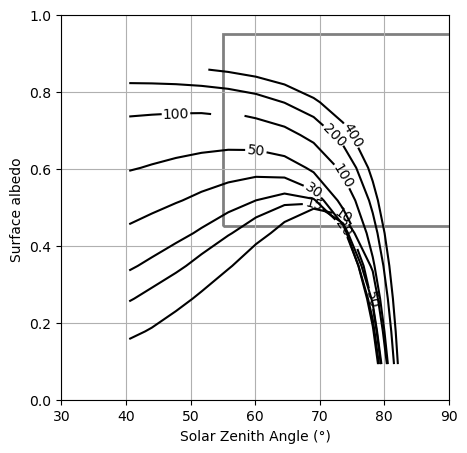

In [8]:
fig, ax = plt.subplots(figsize=(5, 5))

colors = plt.cm.inferno(np.linspace(0, 1, len(ds_cre_total.lwc)))

for i, lwc in enumerate(ds_cre_total.lwc.values):
        
    cs = ds_cre_total_all.isel(altitude=0).sel(lwc=lwc).enet.plot.contour(x='sza', colors='k', levels=[0])
    # add lwc to complete the label 
    cs.clabel(fmt=f'{lwps[i]}', colors='k')

# show SHEBA region
from matplotlib.patches import Rectangle

ax.add_patch(Rectangle((55, .45), 50, .5, alpha=0.5, edgecolor='k', linewidth=2, fill=False))

ax.set_xlim(30, 90)
ax.set_ylim(0, 1)
ax.set_title('')
ax.grid()
ax.set_xlabel('Solar Zenith Angle (°)')
ax.set_ylabel('Surface albedo ')

This looks defenitly more like [Shupe & Intrieri](https://doi.org/10.1175/1520-0442(2004)017<0616:CRFOTA>2.0.CO;2) Fig. 7 (at least to our first approximation in [our first try](notebooks/shupe_and_intrieri_plot.ipynb))! Adding in the profiles from our era5_arctic radiosonde climatology and grouping over sea-ice cover seemed to be a good intuition... Imagine what else we could do with this data!